c:\Users\BroCode\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


c:\Users\BroCode\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.8005 - loss: 0.4223 - val_accuracy: 0.8628 - val_loss: 0.3220
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9026 - loss: 0.2464 - val_accuracy: 0.8672 - val_loss: 0.3204
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.9302 - loss: 0.1833 - val_accuracy: 0.8778 - val_loss: 0.3359
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9566 - loss: 0.1235 - val_accuracy: 0.8582 - val_loss: 0.3691
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.9627 - loss: 0.1065 - val_accuracy: 0.8604 - val_loss: 0.4287
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8576 - loss: 0.4482
Test Accuracy: 0.8575599789619446


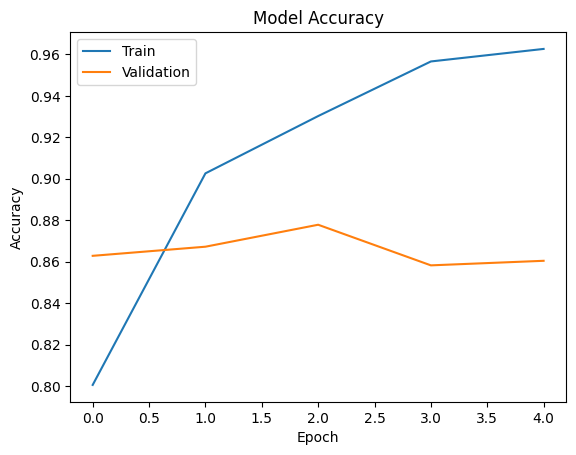

In [1]:
# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 2: Load Dataset
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Step 3: Padding
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Step 4: Build Model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Step 5: Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Step 6: Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Step 7: Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Step 8: Plot Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()